# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"
#!pip install wget

## 2. Imports and Reproducibility


In [2]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [3]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [4]:
def load_har_data(root_dir="UCI HAR Dataset"):
    X_train_path = os.path.join(root_dir, "train", "X_train.txt")
    y_train_path = os.path.join(root_dir, "train", "y_train.txt")
    X_test_path = os.path.join(root_dir, "test", "X_test.txt")
    y_test_path = os.path.join(root_dir, "test", "y_test.txt")

    X_train = np.loadtxt(X_train_path, dtype=np.float32)
    y_train = np.loadtxt(y_train_path, dtype=np.int64) - 1
    X_test = np.loadtxt(X_test_path, dtype=np.float32)
    y_test = np.loadtxt(y_test_path, dtype=np.int64) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
print(f"Number of features: {num_features}, Number of classes: {num_classes}")

X_train shape: (7352, 561), y_train shape: (7352,)
X_test shape: (2947, 561), y_test shape: (2947,)
Number of features: 561, Number of classes: 6


## 5. Quick Inspection

In [5]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

class_counts = np.bincount(y_train, minlength=num_classes)

summary_df = pd.DataFrame({
    "class_index": np.arange(num_classes),
    "class_name": class_names,
    "train_samples": class_counts
})

summary_df

,class_index,class_name,train_samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [6]:
def build_baseline_model(input_dim, num_classes):

    model = keras.Sequential([
        layers.Dense(256, activation="relu", input_shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
92/92 [==============================] - 0s 1ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 903us/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 891us/step - loss: 0.1152 - accuracy: 0.9568 - val_loss: 0.2632 - val_accuracy: 0.9123
Epoch 4/40
92/92 [==============================] - 0s 893us/step - loss: 0.0907 - accuracy: 0.9633 - val_loss: 0.1618 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 882us/step - loss: 0.0905 - accuracy: 0.9646 - val_loss: 0.2719 - val_accuracy: 0.9205
Epoch 6/40
92/92 [==============================] - 0s 883us/step - loss: 0.0712 - accuracy: 0.9723 - val_loss: 0.2235 - val_accuracy: 0.9307
Epoch 7/40
92/92 [==============================] - 0s 881us/step - loss: 0.0588 - accuracy: 0.9776 - val_loss: 0.1442 - val_accuracy: 0.9422
Epoch 8/

### Training Curves


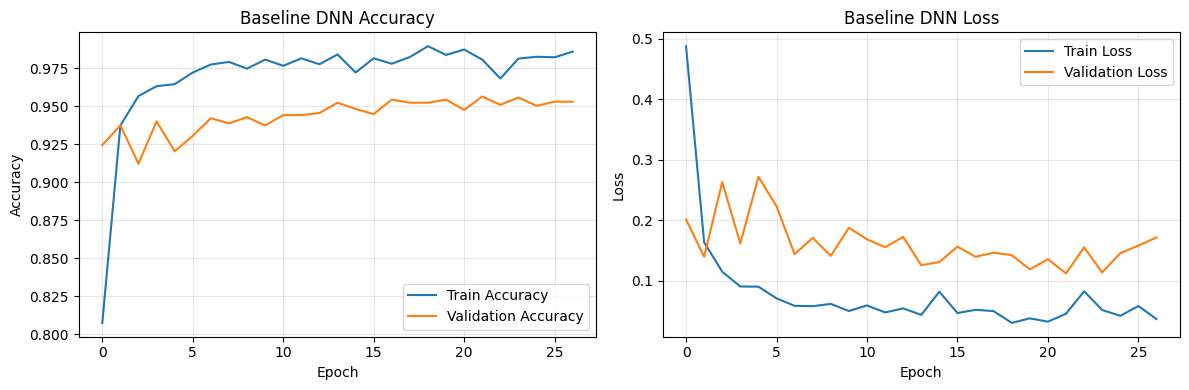

In [8]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

# <-- Enter your code here <--#
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Baseline DNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Baseline DNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Evaluate the Baseline Keras Model


Baseline test accuracy: 0.9264
                    precision    recall  f1-score   support

           WALKING       0.86      1.00      0.92       496
  WALKING_UPSTAIRS       0.95      0.85      0.90       471
WALKING_DOWNSTAIRS       0.97      0.91      0.94       420
           SITTING       0.93      0.89      0.91       491
          STANDING       0.87      0.94      0.90       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



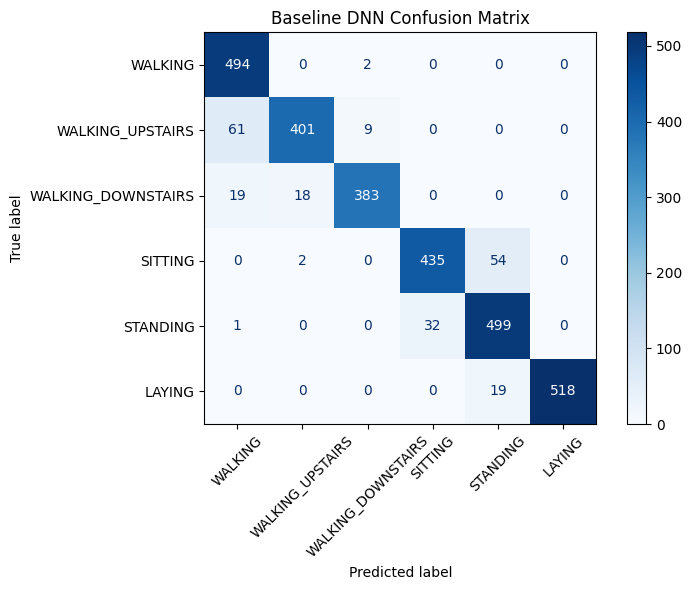

In [9]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
baseline_test_probs = baseline_model.predict(X_test, verbose=0)
baseline_y_pred = np.argmax(baseline_test_probs, axis=1)
baseline_test_acc = accuracy_score(y_test, baseline_y_pred)
print(f"Baseline test accuracy: {baseline_test_acc:.4f}")
print(classification_report(y_test, baseline_y_pred, target_names=class_names))
cm_baseline = confusion_matrix(y_test, baseline_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Baseline DNN Confusion Matrix")
plt.tight_layout()
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [10]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]

    # <-- Enter your code here <--#
    num_samples = min(300, len(X_train))
    for i in range(num_samples):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.


        # <-- Enter your code here <--#
        input_dtype = input_details["dtype"]
        if input_dtype in (np.int8, np.uint8):
            x = np.round(x / input_scale + input_zero_point)
            qmin, qmax = np.iinfo(input_dtype).min, np.iinfo(input_dtype).max
            x = np.clip(x, qmin, qmax).astype(input_dtype)
        else:
            x = x.astype(input_dtype)

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.


        # <-- Enter your code here <--#
        output_dtype = output_details["dtype"]
        if output_dtype in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        else:
            output = output.astype(np.float32)

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()

## 9. Post-Training Quantization (PTQ)


In [11]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#
ptq_fp32_tflite = convert_to_tflite_fp32(baseline_model)
ptq_dynamic_tflite = convert_to_tflite_dynamic_range(baseline_model)
ptq_float16_tflite = convert_to_tflite_float16(baseline_model)
ptq_int8_tflite = convert_to_tflite_int8(baseline_model)
ptq_fp32_size_kb = save_binary_model(ptq_fp32_tflite, "baseline_fp32.tflite")
ptq_dynamic_size_kb = save_binary_model(ptq_dynamic_tflite, "baseline_dynamic_range.tflite")
ptq_float16_size_kb = save_binary_model(ptq_float16_tflite, "baseline_float16.tflite")
ptq_int8_size_kb = save_binary_model(ptq_int8_tflite, "baseline_int8.tflite")
ptq_fp32_acc, ptq_fp32_y_pred = evaluate_tflite_model(ptq_fp32_tflite, X_test, y_test)
ptq_dynamic_acc, ptq_dynamic_y_pred = evaluate_tflite_model(ptq_dynamic_tflite, X_test, y_test)
ptq_float16_acc, ptq_float16_y_pred = evaluate_tflite_model(ptq_float16_tflite, X_test, y_test)
ptq_int8_acc, ptq_int8_y_pred = evaluate_tflite_model(ptq_int8_tflite, X_test, y_test)
ptq_results = [
    {"Model Family": "PTQ", "Format": "FP32", "Test Accuracy": ptq_fp32_acc, "Model Size (KB)": ptq_fp32_size_kb},
    {"Model Family": "PTQ", "Format": "Dynamic Range", "Test Accuracy": ptq_dynamic_acc, "Model Size (KB)": ptq_dynamic_size_kb},
    {"Model Family": "PTQ", "Format": "Float16", "Test Accuracy": ptq_float16_acc, "Model Size (KB)": ptq_float16_size_kb},
    {"Model Family": "PTQ", "Format": "Int8", "Test Accuracy": ptq_int8_acc, "Model Size (KB)": ptq_int8_size_kb}
 ]
for row in ptq_results:
    print(f"{row['Format']}: acc={row['Test Accuracy']:.4f}, size={row['Model Size (KB)']:.2f} KB")

INFO:tensorflow:Assets written to: /var/folders/86/t62q99rn537c17fwg1c0m5c00000gn/T/tmpfmwefjfu/assets


INFO:tensorflow:Assets written to: /var/folders/86/t62q99rn537c17fwg1c0m5c00000gn/T/tmpfmwefjfu/assets
2026-04-16 18:05:27.073829: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-16 18:05:27.073837: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-16 18:05:27.074069: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/86/t62q99rn537c17fwg1c0m5c00000gn/T/tmpfmwefjfu
2026-04-16 18:05:27.074376: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-16 18:05:27.074379: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/86/t62q99rn537c17fwg1c0m5c00000gn/T/tmpfmwefjfu
2026-04-16 18:05:27.075372: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-16 18:05:27.075658: I tensorflow/cc/saved_model/load

INFO:tensorflow:Assets written to: /var/folders/86/t62q99rn537c17fwg1c0m5c00000gn/T/tmpoc1s643j/assets


INFO:tensorflow:Assets written to: /var/folders/86/t62q99rn537c17fwg1c0m5c00000gn/T/tmpoc1s643j/assets
2026-04-16 18:05:27.287619: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-16 18:05:27.287627: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-16 18:05:27.287693: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/86/t62q99rn537c17fwg1c0m5c00000gn/T/tmpoc1s643j
2026-04-16 18:05:27.288009: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-16 18:05:27.288012: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/86/t62q99rn537c17fwg1c0m5c00000gn/T/tmpoc1s643j
2026-04-16 18:05:27.288808: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-16 18:05:27.302193: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/86/t62q99rn537c17fwg1c0m5c00000gn/T/tmp7h8nyzi1/assets


INFO:tensorflow:Assets written to: /var/folders/86/t62q99rn537c17fwg1c0m5c00000gn/T/tmp7h8nyzi1/assets
2026-04-16 18:05:27.477411: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-16 18:05:27.477419: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-16 18:05:27.477481: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/86/t62q99rn537c17fwg1c0m5c00000gn/T/tmp7h8nyzi1
2026-04-16 18:05:27.477756: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-16 18:05:27.477759: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/86/t62q99rn537c17fwg1c0m5c00000gn/T/tmp7h8nyzi1
2026-04-16 18:05:27.478539: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-16 18:05:27.491949: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/86/t62q99rn537c17fwg1c0m5c00000gn/T/tmpw5q3vssv/assets


INFO:tensorflow:Assets written to: /var/folders/86/t62q99rn537c17fwg1c0m5c00000gn/T/tmpw5q3vssv/assets
/Users/aaravwadhwani/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-16 18:05:27.719461: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-16 18:05:27.719468: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-16 18:05:27.719530: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/86/t62q99rn537c17fwg1c0m5c00000gn/T/tmpw5q3vssv
2026-04-16 18:05:27.719807: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-16 18:05:27.719809: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/86/t62q99r

FP32: acc=0.9264, size=726.73 KB
Dynamic Range: acc=0.9260, size=186.12 KB
Float16: acc=0.9264, size=365.72 KB
Int8: acc=0.9257, size=185.34 KB


## 10. PTQ Comparison: Accuracy and Model Size


In [12]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
ptq_comparison_df = pd.DataFrame(ptq_results)
ptq_comparison_df

,Model Family,Format,Test Accuracy,Model Size (KB)
0,PTQ,FP32,0.926366,726.726562
1,PTQ,Dynamic Range,0.926026,186.125000
2,PTQ,Float16,0.926366,365.718750
3,PTQ,Int8,0.925687,185.343750


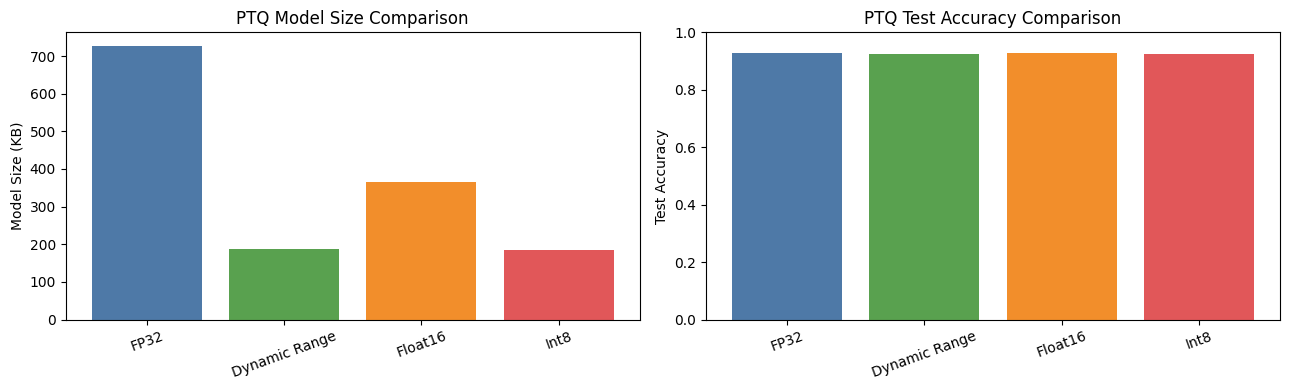

In [13]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(ptq_comparison_df["Format"], ptq_comparison_df["Model Size (KB)"], color=["#4E79A7", "#59A14F", "#F28E2B", "#E15759"])
axes[0].set_title("PTQ Model Size Comparison")
axes[0].set_ylabel("Model Size (KB)")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(ptq_comparison_df["Format"], ptq_comparison_df["Test Accuracy"], color=["#4E79A7", "#59A14F", "#F28E2B", "#E15759"])
axes[1].set_title("PTQ Test Accuracy Comparison")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model


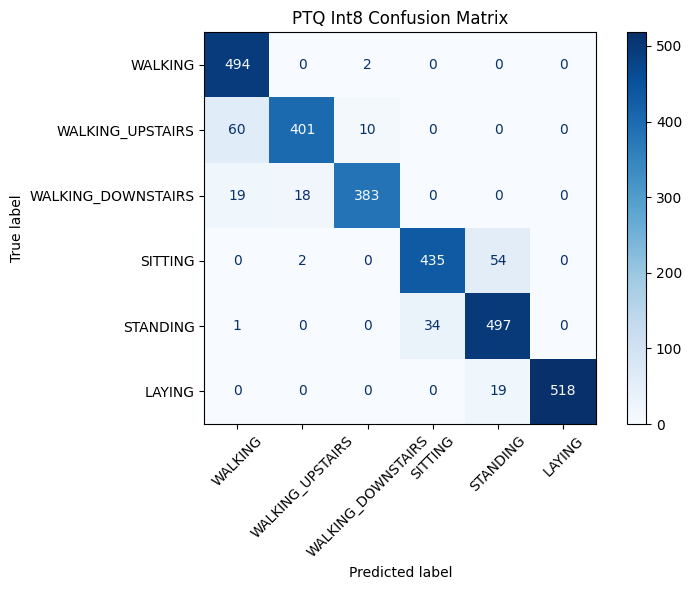

                    precision    recall  f1-score   support

           WALKING       0.86      1.00      0.92       496
  WALKING_UPSTAIRS       0.95      0.85      0.90       471
WALKING_DOWNSTAIRS       0.97      0.91      0.94       420
           SITTING       0.93      0.89      0.91       491
          STANDING       0.87      0.93      0.90       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



In [14]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#
cm_ptq_int8 = confusion_matrix(y_test, ptq_int8_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_ptq_int8, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("PTQ Int8 Confusion Matrix")
plt.tight_layout()
plt.show()
print(classification_report(y_test, ptq_int8_y_pred, target_names=class_names))

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [15]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
qat_model = tfmot.quantization.keras.quantize_model(baseline_model)
qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
qat_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_dense (QuantizeWrapp  (None, 256)               143877    
 erV2)                                                           
                                                                 
 quant_dense_1 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_2 (QuantizeWra  (None, 64)                8261      
 pperV2)                                                         
                                                                 
 quant_dense_3 (QuantizeWra  (None, 6)                 3

### Fine-Tune the QAT Model


In [16]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#
qat_history = qat_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1
)

Epoch 1/8
92/92 [==============================] - 0s 2ms/step - loss: 0.0283 - accuracy: 0.9917 - val_loss: 0.1256 - val_accuracy: 0.9579
Epoch 2/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0236 - accuracy: 0.9915 - val_loss: 0.1253 - val_accuracy: 0.9585
Epoch 3/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0223 - accuracy: 0.9929 - val_loss: 0.1286 - val_accuracy: 0.9572
Epoch 4/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0207 - accuracy: 0.9929 - val_loss: 0.1269 - val_accuracy: 0.9579
Epoch 5/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0195 - accuracy: 0.9935 - val_loss: 0.1533 - val_accuracy: 0.9551
Epoch 6/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0215 - accuracy: 0.9920 - val_loss: 0.1419 - val_accuracy: 0.9572
Epoch 7/8
92/92 [==============================] - 0s 1ms/step - loss: 0.0190 - accuracy: 0.9932 - val_loss: 0.1332 - val_accuracy: 0.9585
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model


In [17]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#
qat_test_probs = qat_model.predict(X_test, verbose=0)
qat_keras_y_pred = np.argmax(qat_test_probs, axis=1)
qat_keras_acc = accuracy_score(y_test, qat_keras_y_pred)
print(f"QAT Keras test accuracy: {qat_keras_acc:.4f}")
print(classification_report(y_test, qat_keras_y_pred, target_names=class_names))

QAT Keras test accuracy: 0.9362
                    precision    recall  f1-score   support

           WALKING       0.93      0.98      0.95       496
  WALKING_UPSTAIRS       0.92      0.93      0.92       471
WALKING_DOWNSTAIRS       0.97      0.92      0.94       420
           SITTING       0.96      0.87      0.91       491
          STANDING       0.86      0.97      0.91       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.93      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [18]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#
qat_int8_tflite = convert_to_tflite_int8(qat_model)
qat_int8_size_kb = save_binary_model(qat_int8_tflite, "qat_int8.tflite")
qat_int8_acc, qat_int8_y_pred = evaluate_tflite_model(qat_int8_tflite, X_test, y_test)
print(f"QAT Int8: acc={qat_int8_acc:.4f}, size={qat_int8_size_kb:.2f} KB")

INFO:tensorflow:Assets written to: /var/folders/86/t62q99rn537c17fwg1c0m5c00000gn/T/tmpf41sb7gy/assets


INFO:tensorflow:Assets written to: /var/folders/86/t62q99rn537c17fwg1c0m5c00000gn/T/tmpf41sb7gy/assets
/Users/aaravwadhwani/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-16 18:05:30.028158: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-16 18:05:30.028166: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-16 18:05:30.028229: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/86/t62q99rn537c17fwg1c0m5c00000gn/T/tmpf41sb7gy
2026-04-16 18:05:30.028894: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-16 18:05:30.028897: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/86/t62q99r

QAT Int8: acc=0.9362, size=185.70 KB


## 12. PTQ Int8 vs QAT Int8


In [19]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
ptq_vs_qat_int8_df = pd.DataFrame([
    {"Model": "PTQ Int8", "Test Accuracy": ptq_int8_acc, "Model Size (KB)": ptq_int8_size_kb},
    {"Model": "QAT Int8", "Test Accuracy": qat_int8_acc, "Model Size (KB)": qat_int8_size_kb}
])
ptq_vs_qat_int8_df

,Model,Test Accuracy,Model Size (KB)
0,PTQ Int8,0.925687,185.343750
1,QAT Int8,0.936206,185.695312


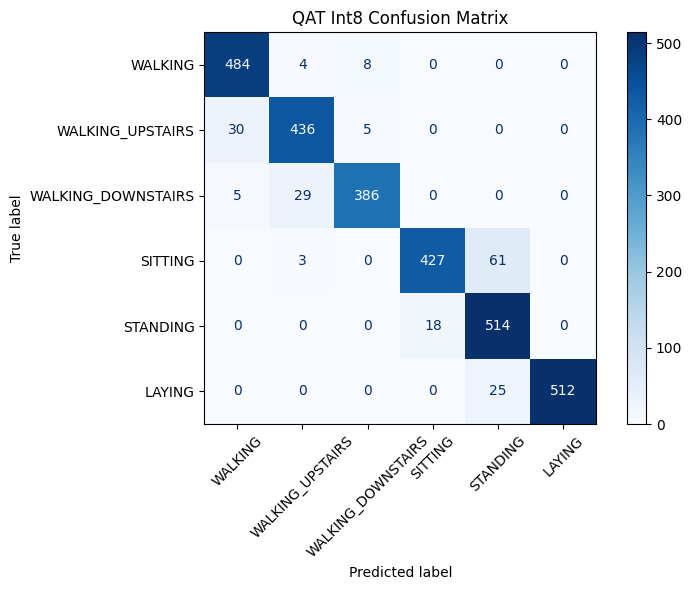

In [20]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#
cm_qat_int8 = confusion_matrix(y_test, qat_int8_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_qat_int8, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("QAT Int8 Confusion Matrix")
plt.tight_layout()
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
Answer: PTQ Int8 gave the smallest model size at about 185.34 KB.

2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
Answer: QAT Int8 gave the best TensorFlow Lite accuracy at about 0.9362.

3. Did QAT improve the final int8 model compared with PTQ int8?
Answer: Yes. PTQ Int8 accuracy was about 0.9257, while QAT Int8 reached about 0.9362, an improvement of about 0.0105 (1.05 percentage points), with only a small size increase (about 185.34 KB to 185.70 KB).

4. Why is this dataset a good fit for a DNN-based TinyML workflow?
Answer: The dataset is already converted into a compact fixed-length numerical feature vector (561 features), so a small dense network works well without heavy signal-processing models. It has a moderate number of classes (6) and supports good accuracy with compact models that can be quantized for embedded deployment.

5. If you were deploying this model on a resource-constrained device, which version would you choose and why?
Answer: I would choose the QAT Int8 model because it provides the best accuracy while keeping model size very close to the smallest PTQ Int8 model, giving the best accuracy-memory tradeoff for deployment.


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
